# **Modelado — scikit-learn**

Se entrena un `RandomForestClassifier` con búsqueda de hiperparámetros via `GridSearchCV`.

> **¿Por qué ROC AUC como scoring?** Con un dataset desbalanceado 80/20, ROC AUC evalúa
> la capacidad del modelo para **separar las dos clases a lo largo de todos los umbrales**,
> sin asumir un punto de corte fijo. Esto lo hace consistente con el evaluador nativo de
> PySpark (`BinaryClassificationEvaluator`), facilitando la comparación directa entre ambos
> frameworks. Las métricas dependientes del umbral (F1, Precision, Recall) se reportan
> igualmente en la evaluación final.

## **GridSearchCV — Búsqueda de Hiperparámetros**

In [ ]:
import time
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Grid de hiperparámetros
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth'   : [5, 10, 15]
}

# Estrategia de validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator          = rf,
    param_grid         = param_grid,
    cv                 = cv,
    scoring            = 'roc_auc',
    n_jobs             = -1,
    verbose            = 1,
    return_train_score = True
)

print(f'Iniciando GridSearchCV')
t0 = time.time()
grid_search.fit(X_train_sk, y_train)
t_gridsearch = time.time() - t0

print(f'\nTiempo GridSearchCV : {t_gridsearch:.1f}s  ({t_gridsearch/60:.1f} min)')
print(f'Mejor combinación   : {grid_search.best_params_}')
print(f'Mejor ROC AUC (CV)  : {grid_search.best_score_:.4f}')

Iniciando GridSearchCV
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Tiempo GridSearchCV : 1209.7s  (20.2 min)
Mejor combinación   : {'max_depth': 15, 'n_estimators': 100}
Mejor ROC AUC (CV)  : 0.7033


## **Resultados del GridSearchCV — Tabla Comparativa**

In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cols_show = [
    'param_n_estimators', 'param_max_depth',
    'mean_train_score', 'std_train_score',
    'mean_test_score',  'std_test_score',
    'mean_fit_time'
]
cv_table = (
    cv_results[cols_show]
    .rename(columns={
        'param_n_estimators' : 'n_estimators',
        'param_max_depth'    : 'max_depth',
        'mean_train_score'   : 'AUC_train_mean',
        'std_train_score'    : 'AUC_train_std',
        'mean_test_score'    : 'AUC_val_mean',
        'std_test_score'     : 'AUC_val_std',
        'mean_fit_time'      : 'fit_time_s'
    })
    .sort_values('AUC_val_mean', ascending=False)
    .reset_index(drop=True)
)
cv_table = cv_table.round(4)
print('── Resultados ordenados por ROC AUC de validación ──')
print(cv_table.to_string(index=False))

── Resultados ordenados por ROC AUC de validación ──
 n_estimators  max_depth  AUC_train_mean  AUC_train_std  AUC_val_mean  AUC_val_std  fit_time_s
          100         15          0.7510         0.0005        0.7033       0.0016    212.2749
           50         15          0.7501         0.0002        0.7027       0.0014    122.5974
          100         10          0.7079         0.0004        0.6995       0.0016    179.0316
           50         10          0.7077         0.0004        0.6993       0.0018     89.4771
           10         15          0.7447         0.0008        0.6967       0.0018     28.9830
           10         10          0.7050         0.0007        0.6965       0.0021     20.8058
          100          5          0.6928         0.0007        0.6918       0.0014     94.7905
           50          5          0.6925         0.0009        0.6915       0.0015     50.0889
           10          5          0.6849         0.0010        0.6840       0.0016     12.17

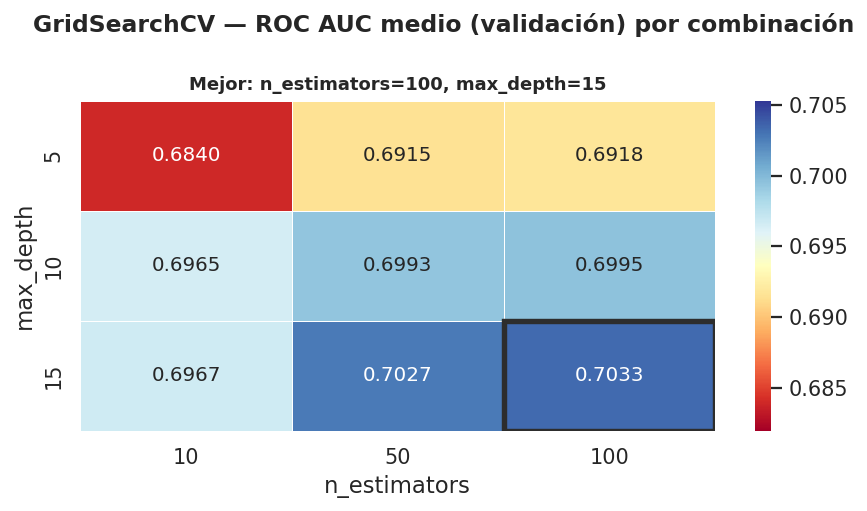

In [ ]:
# Heatmap ROC AUC por combinación de hiperparámetros
pivot = cv_table.pivot(index='max_depth', columns='n_estimators', values='AUC_val_mean')
pivot.index   = pivot.index.astype(int)
pivot.columns = pivot.columns.astype(int)

fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle('GridSearchCV — ROC AUC medio (validación) por combinación', fontsize=13, fontweight='bold')

sns.heatmap(
    pivot,
    annot=True, fmt='.4f',
    cmap='RdYlBu',
    vmin=pivot.values.min() - 0.002,
    vmax=pivot.values.max() + 0.002,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11},
    ax=ax
)
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')

# Marcar la mejor celda
best_ne = grid_search.best_params_['n_estimators']
best_md = grid_search.best_params_['max_depth']
best_col = list(pivot.columns).index(best_ne)
best_row = list(pivot.index).index(best_md)
ax.add_patch(plt.Rectangle((best_col, best_row), 1, 1, fill=False,
                             edgecolor='#2d2d2d', linewidth=3))
ax.set_title(f'Mejor: n_estimators={best_ne}, max_depth={best_md}', fontsize=10)

plt.tight_layout()
plt.show()

## **Evaluación Final — Mejor Modelo sobre Test**

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

best_model = grid_search.best_estimator_

# Predicciones
t0 = time.time()
y_pred      = best_model.predict(X_test_sk)
y_pred_prob = best_model.predict_proba(X_test_sk)[:, 1]
t_pred = time.time() - t0

# Métricas
metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1-Score' : f1_score(y_test, y_pred),
    'ROC AUC'  : roc_auc_score(y_test, y_pred_prob)
}

print('── Métricas sobre Test ──')
print(f'  Mejor modelo : n_estimators={best_model.n_estimators}, max_depth={best_model.max_depth}')
print(f'  Tiempo pred  : {t_pred:.3f}s\n')
for name, val in metrics.items():
    print(f'  {name:12s}: {val:.4f}')

print(f'\n── Classification Report ──')
print(classification_report(y_test, y_pred, target_names=['Fully Paid', 'Charged Off']))

# Guardar tiempos para comparación posterior con PySpark
sk_times = {'gridsearch': t_gridsearch, 'predict': t_pred}

── Métricas sobre Test ──
  Mejor modelo : n_estimators=100, max_depth=15
  Tiempo pred  : 1.886s

  Accuracy    : 0.8006
  Precision   : 0.6570
  Recall      : 0.0021
  F1-Score    : 0.0042
  ROC AUC     : 0.7031

── Classification Report ──
              precision    recall  f1-score   support

  Fully Paid       0.80      1.00      0.89    215350
 Charged Off       0.66      0.00      0.00     53712

    accuracy                           0.80    269062
   macro avg       0.73      0.50      0.45    269062
weighted avg       0.77      0.80      0.71    269062



## **Matriz de Confusión**

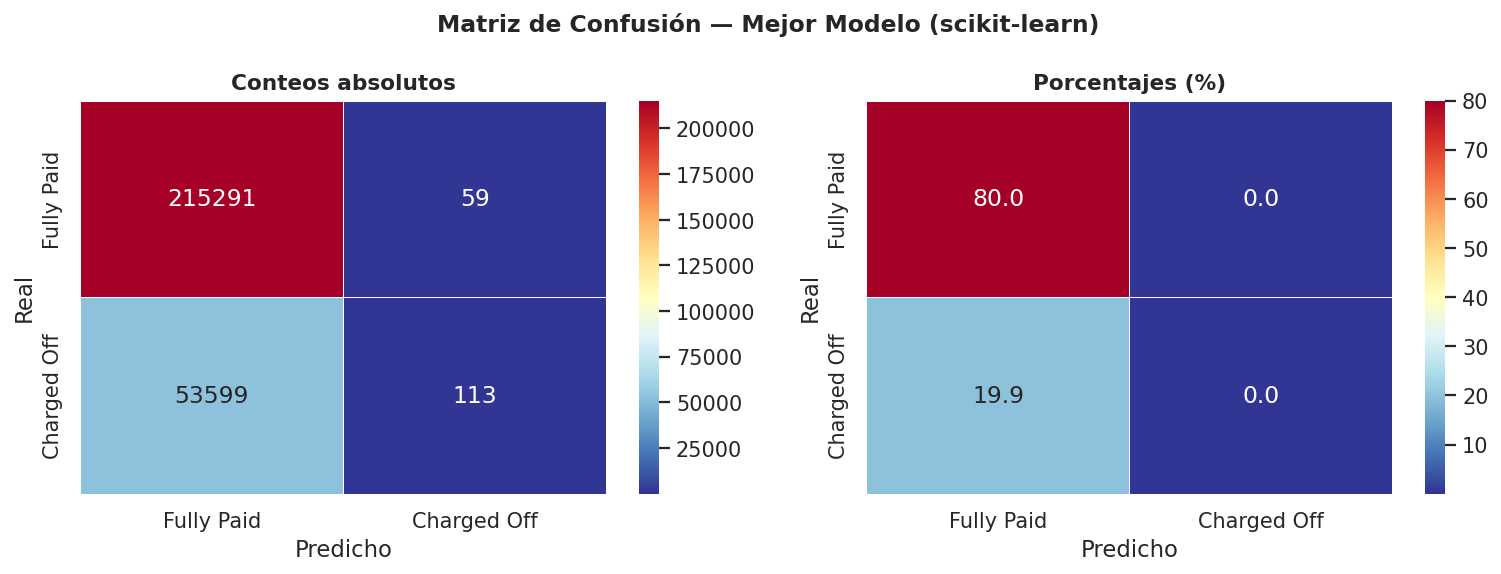

Verdaderos Negativos (TN) :  215,291  — Fully Paid correctamente identificados
Falsos Positivos     (FP) :       59  — Fully Paid clasificados como default
Falsos Negativos     (FN) :   53,599  — Defaults NO detectados
Verdaderos Positivos (TP) :      113  — Defaults correctamente detectados


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm / cm.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Matriz de Confusión — Mejor Modelo (scikit-learn)', fontsize=13, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_pct],
    ['d', '.1f'],
    ['Conteos absolutos', 'Porcentajes (%)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt,
        cmap='RdYlBu_r',
        xticklabels=['Fully Paid', 'Charged Off'],
        yticklabels=['Fully Paid', 'Charged Off'],
        linewidths=0.5, linecolor='white',
        annot_kws={'size': 13},
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (TN) : {tn:>8,}  — Fully Paid correctamente identificados')
print(f'Falsos Positivos     (FP) : {fp:>8,}  — Fully Paid clasificados como default')
print(f'Falsos Negativos     (FN) : {fn:>8,}  — Defaults NO detectados')
print(f'Verdaderos Positivos (TP) : {tp:>8,}  — Defaults correctamente detectados')

## **Curva ROC**

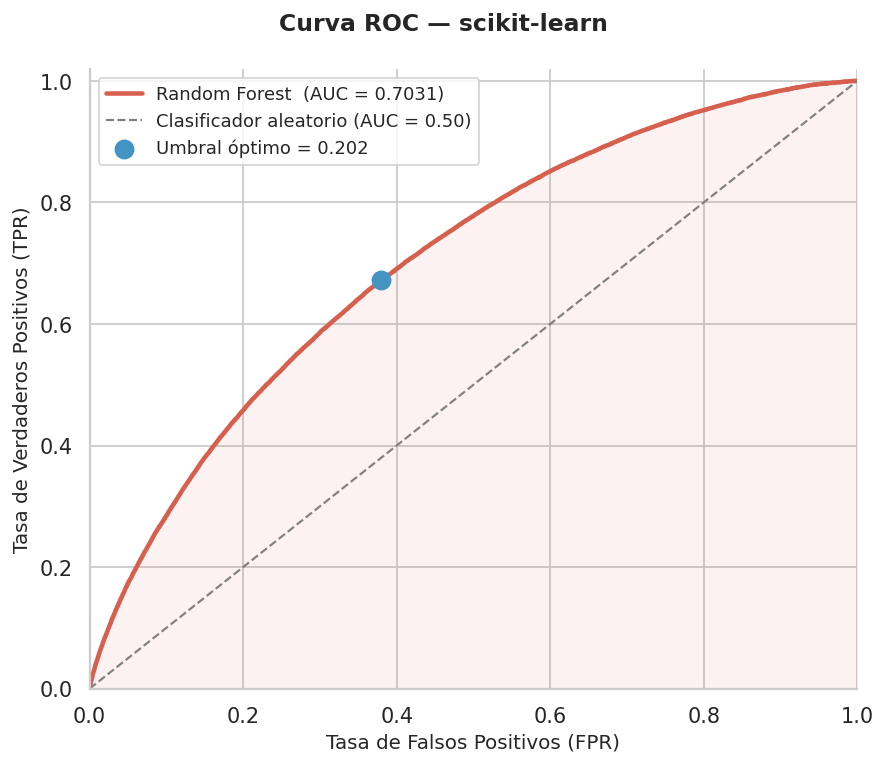

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = metrics['ROC AUC']

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Curva ROC — scikit-learn', fontsize=13, fontweight='bold')

ax.plot(fpr, tpr, color=C_DEFAULT, linewidth=2.5,
        label=f'Random Forest  (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1.2,
        linestyle='--', label='Clasificador aleatorio (AUC = 0.50)')

# Punto óptimo — máximo de (TPR - FPR)
optimal_idx = (tpr - fpr).argmax()
ax.scatter(fpr[optimal_idx], tpr[optimal_idx],
           color=C_PAID, s=100, zorder=5,
           label=f'Umbral óptimo = {thresholds[optimal_idx]:.3f}')

ax.fill_between(fpr, tpr, alpha=0.08, color=C_DEFAULT)
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

En **GridSearchCV** la mejor combinación fue n_estimators=100, max_depth=15 con ROC AUC de 0.7033 en validación cruzada. La tabla de resultados muestra un patrón claro: max_depth=15 domina en todas las configuraciones de n_estimators, sin embargo la diferencia entre max_depth=10 y max_depth=15 es pequeña (0.6995 vs 0.7033), lo que sugiere que el modelo empieza a estabilizarse en esa profundidad. El overfitting es visible — el AUC en train (0.7510) es notablemente superior al de validación (0.7033).

El resultado más preocupante es Accuracy 0.80, ROC AUC 0.70, pero Recall de 0.0021 y F1 de 0.0042. En la matriz de confusión: 53,599 Falsos Negativos frente a apenas 113 Verdaderos Positivos. El modelo aprendió a decir "Fully Paid" casi siempre, lo que le da buen accuracy pero es inútil desde el punto de vista financiero.

## **Importancia de Features — Top 20**

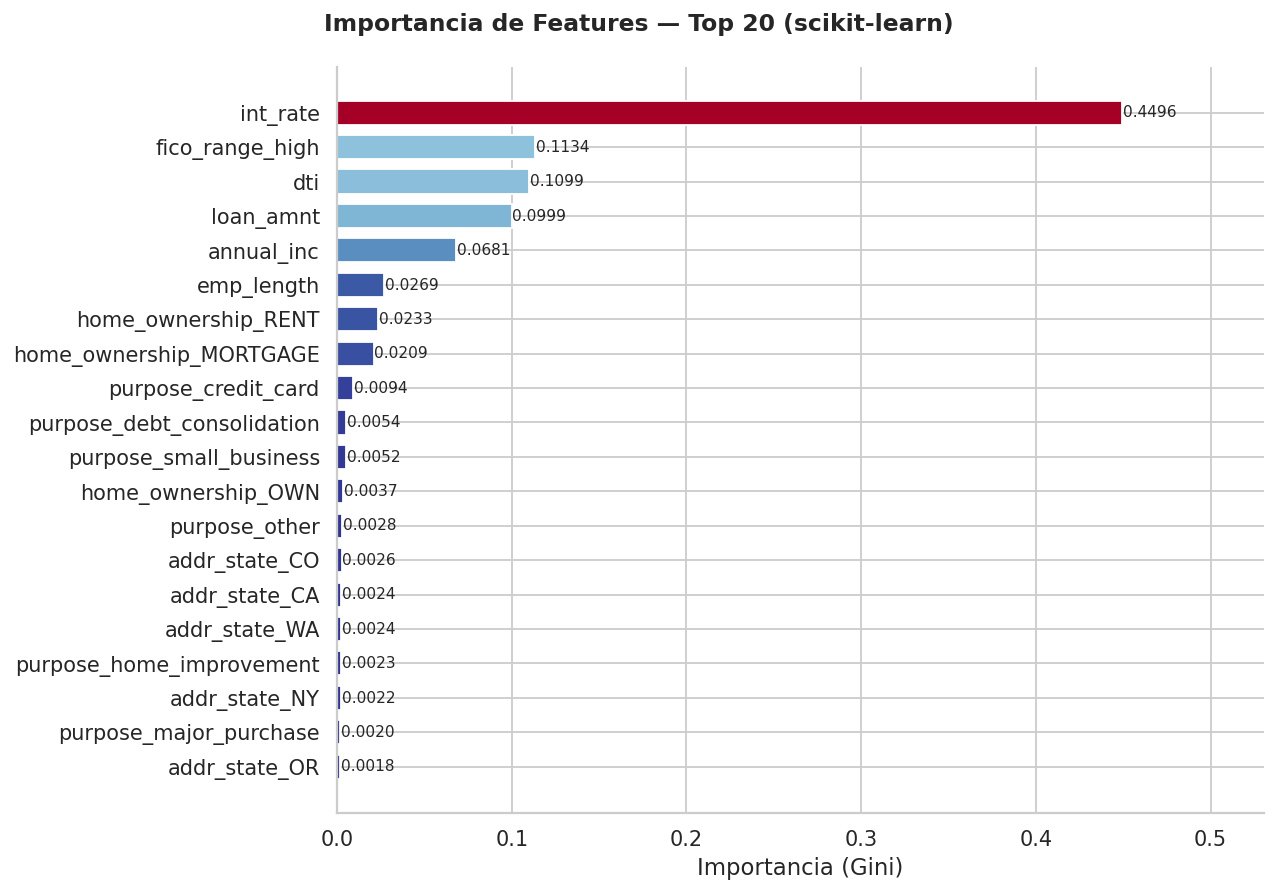

── Top 10 features ──
                   feature  importance
                  int_rate    0.449585
           fico_range_high    0.113367
                       dti    0.109900
                 loan_amnt    0.099911
                annual_inc    0.068062
                emp_length    0.026949
       home_ownership_RENT    0.023348
   home_ownership_MORTGAGE    0.020922
       purpose_credit_card    0.009377
purpose_debt_consolidation    0.005350


In [ ]:
importances = best_model.feature_importances_
fi_df = (
    pd.DataFrame({'feature': all_feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# Colorear por importancia (RdYlBu_r: rojo = más importante)
norm_fi = (fi_df['importance'] - fi_df['importance'].min()) / \
          (fi_df['importance'].max() - fi_df['importance'].min() + 1e-9)
colors = plt.cm.RdYlBu_r(norm_fi)

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Importancia de Features — Top 20 (scikit-learn)', fontsize=13, fontweight='bold')

bars = ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
               color=colors[::-1], edgecolor='white', height=0.7)

for bar, val in zip(bars, fi_df['importance'][::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)

ax.set_xlabel('Importancia (Gini)')
ax.set_xlim(0, fi_df['importance'].max() * 1.18)

plt.tight_layout()
plt.show()

print('── Top 10 features ──')
print(fi_df.head(10).to_string(index=False))

int_rate domina con 44.9% de importancia. Casi la mitad del poder predictivo del modelo descansa en una sola variable. Le siguen fico_range_high (11.3%), dti (11.0%) y loan_amnt (10.0%). Las variables categóricas aportan poco individualmente, con home_ownership_RENT como la más relevante (2.3%). emp_length apenas alcanza 2.7%, confirmando lo que los gráficos del EDA anticipaban (poca capacidad discriminativa).